# 4 · Results: reproduction vs. paper

This notebook gathers the cached runs (created by notebook 3 or by
`python scripts/run_experiments.py --fv FV1 FV2`) and compares them with the paper's
Tables 10–13 and Figures 3–5.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # make `lora_loc` importable from notebooks/
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lora_loc import config, data, preprocessing as pp, features, geo, plotting
plotting.style()
pd.set_option("display.precision", 2)
from lora_loc import models, experiment, paper_results as paper
res = experiment.collect()
res = res.set_index(["fv", "model"]).sort_index()
available_fvs = sorted(res.index.get_level_values(0).unique(), key=lambda s: int(s[2:]))
print("feature vectors with results:", available_fvs)

feature vectors with results: ['FV1', 'FV2']


## 4.1 Mean error per feature vector (Tables 10–11)

In [2]:
rows = []
for fv in available_fvs:
    for name in models.MODEL_NAMES:
        if (fv, name) in res.index:
            ours = res.loc[(fv, name), "mean_m"]; ref = paper.MEAN_ERROR_M.loc[name, fv]
            rows.append({"FV": fv, "model": name, "ours (m)": ours, "paper (m)": ref,
                         "Δ (m)": ours - ref, "Δ (%)": 100 * (ours - ref) / ref})
cmp = pd.DataFrame(rows).set_index(["FV", "model"])
display(cmp.round(2))
print("mean |Δ| per FV (m):"); print(cmp["Δ (m)"].abs().groupby(level=0).mean().round(2).to_string())

ours (m)  paper (m)  Δ (m)  Δ (%)
FV  model                                      
FV1 k-NN        336.51     338.56  -2.05  -0.60
    CNN         354.01     343.88  10.13   2.95
    SVR         334.35     331.92   2.43   0.73
    ANN         354.43     332.74  21.69   6.52
    XGBoost     329.33     327.66   1.67   0.51
    LightGBM    326.75     325.43   1.32   0.41
    Hybrid      326.72     323.38   3.34   1.03
FV2 k-NN        331.74     326.26   5.48   1.68
    CNN         343.34     341.39   1.95   0.57
    SVR         376.22     321.93  54.29  16.86
    ANN         347.11     329.84  17.27   5.24
    XGBoost     320.43     318.95   1.48   0.46
    LightGBM    317.19     316.59   0.60   0.19
    Hybrid      321.53     314.21   7.32   2.33

mean |Δ| per FV (m):
FV
FV1     6.09
FV2    12.63


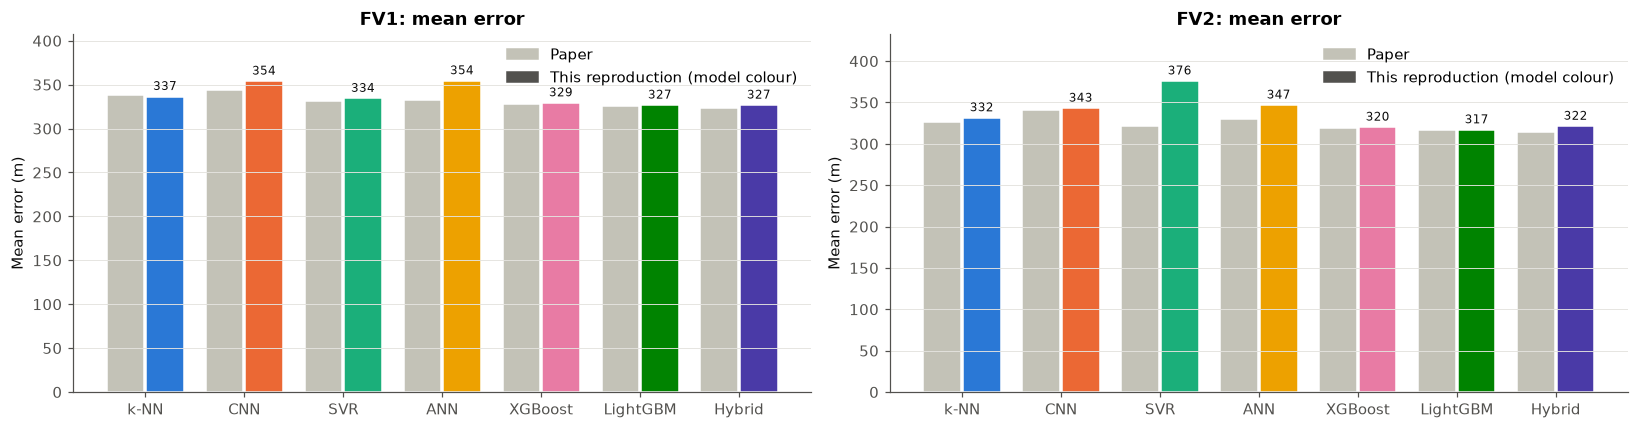

In [3]:
fig, axes = plt.subplots(1, len(available_fvs), figsize=(7.5 * len(available_fvs), 4), squeeze=False)
for ax, fv in zip(axes[0], available_fvs):
    ours = res.loc[fv, "mean_m"]
    plotting.compare_bars(ours, paper.MEAN_ERROR_M[fv], ax=ax, title=f"{fv}: mean error")
    ax.set_ylim(0, max(ours.max(), 350) * 1.15)
plt.tight_layout(); plt.show()

## 4.2 Error distributions (Fig. 3, Table 12)

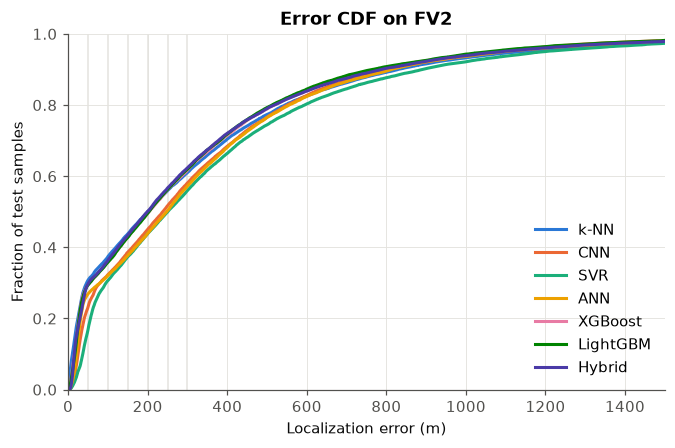

Reproduced, FV2 (fraction of test samples):


,≤50 m,≤100 m,≤150 m,≤200 m,≤250 m,≤300 m
model,,,,,,
ANN,27,32,38,44,50,57
CNN,23,32,39,45,52,58
Hybrid,30,36,43,50,57,62
LightGBM,29,36,43,50,56,62
SVR,17,31,37,44,50,56
XGBoost,29,36,43,49,56,62
k-NN,31,37,44,50,56,61


Paper Table 12 (best FV per model, mostly FV4/FV15/FV16 — not directly comparable):


,50,100,150,200,250,300
k-NN,33,41,48,55,61,66
CNN,3,25,40,47,54,61
SVR,15,35,43,40,57,63
ANN,28,37,45,53,60,66
XGBoost,32,42,50,58,65,71
LightGBM,32,41,50,59,65,71
Hybrid,34,44,52,60,66,72


In [4]:
best_fv = available_fvs[-1]
errs = {name: experiment.run(name, best_fv, verbose=False)["errors_m"]
        for name in models.MODEL_NAMES if (best_fv, name) in res.index}
plotting.cdf(errs, xmax=1500, thresholds=config.CDF_THRESHOLDS_M)
plt.title(f"Error CDF on {best_fv}"); plt.show()

cols = [f"within_{t}m" for t in config.CDF_THRESHOLDS_M]
tab = res.loc[best_fv, cols].copy(); tab.columns = [f"≤{t} m" for t in config.CDF_THRESHOLDS_M]
print(f"Reproduced, {best_fv} (fraction of test samples):"); display((tab * 100).round(0).astype(int))
print("Paper Table 12 (best FV per model, mostly FV4/FV15/FV16 — not directly comparable):")
display((paper.CDF_TABLE12 * 100).round(0).astype(int))

Summary statistics. The paper's Eq. 20 SD is the population SD of the per-sample errors.

In [5]:
stats = res[["mean_m", "median_m", "sd_m", "p90_m", "max_m", "r2_lat", "r2_lon"]]
display(stats.round(3))

mean_m  median_m    sd_m   p90_m    max_m  r2_lat  r2_lon
fv  model                                                              
FV1 ANN       354.43    248.34  392.32  820.51  4989.81    0.94    0.89
    CNN       354.01    244.89  386.32  820.86  4661.02    0.95    0.89
    Hybrid    326.72    201.10  402.44  805.37  5259.61    0.95    0.89
    LightGBM  326.75    210.55  394.75  790.19  5049.31    0.95    0.89
    SVR       334.35    204.88  394.86  806.29  5055.38    0.95    0.89
    XGBoost   329.33    209.19  399.06  804.66  4999.27    0.95    0.89
    k-NN      336.51    207.01  414.76  835.07  5148.18    0.94    0.88
FV2 ANN       347.11    247.70  392.18  812.14  4973.39    0.95    0.89
    CNN       343.34    237.87  385.95  799.09  4669.20    0.95    0.89
    Hybrid    321.53    199.24  401.34  788.15  5316.81    0.95    0.89
    LightGBM  317.19    203.22  387.02  765.18  5232.70    0.95    0.90
    SVR       376.21    250.34  426.91  890.03  5364.37    0.94    0.86
    XGBoost   320.43    203.81  392.37  781.41  5161.49    0.95    0.90
    k-NN      331.74    199.53  417.52  829.39  5147.12    0.94    0.88

## 4.3 Where are the errors? (Fig. 4)

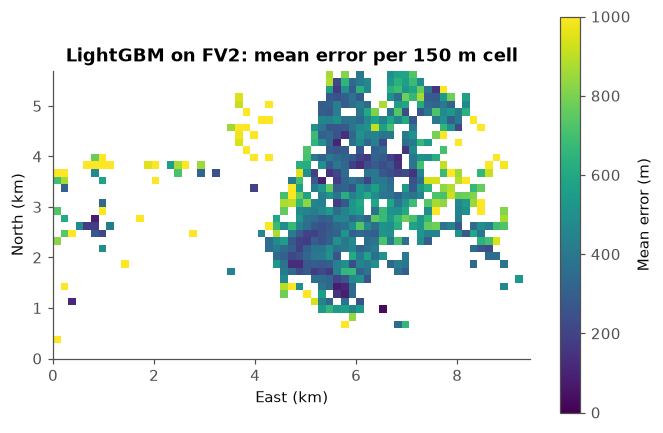

{'cells_below_250m': '10.5%', 'cells_below_300m': '19.5%', 'cells_below_350m': '28.6%'}
paper (Hybrid, best FV): 21.7% of cells < 250 m, 33% < 300 m, 42.6% < 350 m


In [6]:
best = res.loc[best_fv, "mean_m"].idxmin()
r = experiment.run(best, best_fv, verbose=False)
ax, share = plotting.error_heatmap(r["y_true_deg"], r["errors_m"], cell_m=150)
ax.set_title(f"{best} on {best_fv}: mean error per 150 m cell"); plt.show()
print({k: f"{v:.1%}" for k, v in share.items()})
print("paper (Hybrid, best FV): 21.7% of cells < 250 m, 33% < 300 m, 42.6% < 350 m")

Large errors cluster on the periphery of the covered area, most visibly in the sparsely
sampled western part. There, few training fingerprints exist and messages are often heard by a
single gateway. The dense city centre has the lowest errors.

The paper's cell statistics (21.7 % / 33 % / 42.6 % of cells below 250 / 300 / 350 m) are for
the Hybrid on its best FV (FV4, mean 244.5 m), so they are not directly comparable with an
FV1/FV2 map.

## 4.4 Inference time (Fig. 5)
Per-sample prediction time, measured by predicting one sample at a time on 200 random test
samples. Absolute numbers depend on the hardware. Our CPU is not the authors' machine, so compare
the **ranking**, not the values.

In [7]:
t = res.loc[best_fv, ["infer_single_mean_s", "infer_batched_s", "train_s"]].copy()
t["paper per-sample (s)"] = pd.Series(paper.INFERENCE_S)
display(t.rename(columns={"infer_single_mean_s": "ours per-sample (s)",
                          "infer_batched_s": "ours batched, per sample (s)",
                          "train_s": "ours training (s)"}).round(5))

,ours per-sample (s),"ours batched, per sample (s)",ours training (s),paper per-sample (s)
model,,,,
ANN,7.22e-02,1.00e-05,1.86e+02,5.68e-02
CNN,7.11e-02,1.00e-05,1.60e+03,1.49e-01
Hybrid,7.78e-02,1.00e-05,1.23e+03,3.00e-01
LightGBM,2.76e-03,1.40e-04,2.30e+01,2.46e-03
SVR,1.11e-02,8.97e-03,7.49e+02,1.13e-02
XGBoost,2.53e-03,1.00e-05,9.47e+00,9.60e-04
k-NN,2.20e-03,9.20e-04,2.68e-03,1.06e-02


## 4.5 FV3–FV16 (needs the JSON release)

In [8]:
if config.JSON_FILE.exists():
    for fv in [f"FV{i}" for i in range(3, 17)]:
        d = experiment.prepare_fv(fv)
        for name in ["k-NN", "XGBoost", "LightGBM"]:   # add more models if you have the time
            experiment.run(name, fv, prepared=d)
    print("Re-run this notebook from the top to include FV3-FV16 in the tables above.")
else:
    print(f"{config.JSON_FILE.name} not found -> FV3-FV16 skipped.\n"
          "Download it with `python scripts/download_data.py --json`, then re-run this cell.")

lorawan_antwerp_2019_dataset.json.txt not found -> FV3-FV16 skipped.
Download it with `python scripts/download_data.py --json`, then re-run this cell.


## 4.6 Discussion: what reproduces, what does not, and why

See the **Reproduction report** section of the repository `README.md` for the final numbers
from our run and a full list of deviations. The key points for students:

1. **The protocol reproduces exactly.** Dataset checksum, 44 active gateways, −200 → −128 dBm,
   and split sizes (91,300 / 19,564 / 19,565) all match the paper.
2. **The tree models and k-NN reproduce within about 0.5–2 % on FV1 and FV2** (XGBoost, LightGBM,
   k-NN; the full k-NN grid of Table 1 too). SVR and the Hybrid reproduce within about 1 % on FV1.
   The larger gaps are the ANN (+22 m on FV1; the learning rate is not reported, and 1e-4 was the
   best of the rates we tried), the CNN (+10 m on FV1), and **SVR on FV2 (+54 m)**. For SVR the paper
   says it used additional feature selection and random search beyond the grid, without giving
   details, so the FV2 configuration cannot be reproduced from the text. Other sources of gaps are
   unreported details (SVR γ, hybrid kernel size / T), random initialisation of the neural networks,
   and library versions.
3. **Differences between the tree models are within a few metres,** which is about the size of the
   run-to-run variation of the neural models. Rankings between close models should not be
   over-interpreted without repeated runs (different seeds) and confidence intervals.
4. **RSSI-only fingerprinting in this dataset has a floor of roughly 300 m on average**, set by
   sparse coverage (many messages heard by one gateway). The paper's gains to ≈245 m come from
   FVs with the **frame counter**, which, under a random per-message split, may encode
   track continuity rather than radio information that transfers to new devices (see notebook 2).
5. **Median ≪ mean:** the error distribution has a heavy tail, so report median, 90th percentile
   and the CDF, not just the mean.